Importing Dependencies

In [1]:
import os
import joblib 
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score,classification_report

c:\Users\Rajasekar\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Suppress Optuna optimization logging noise

In [2]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

Loading the dataset

In [3]:
df = pd.read_csv("creditcard.csv")

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Checking for Null values

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Data Visualization

In [7]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [8]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

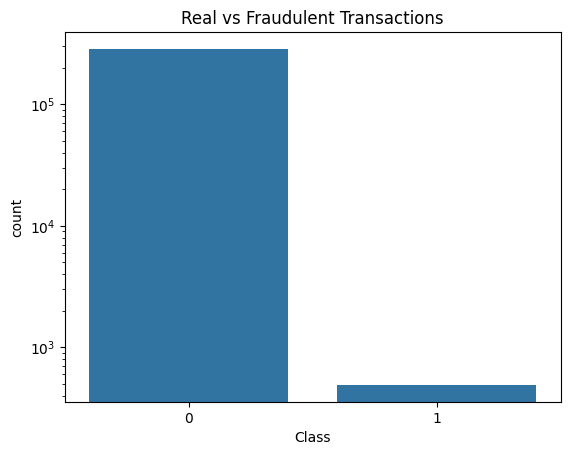

In [9]:
sns.countplot(x="Class", data=df)
plt.title("Real vs Fraudulent Transactions")
plt.yscale("log")
plt.show()

Fraudulent transactions make up 0.17 % of the data (inferred from above)

Finding the best fingerprints (Feature Separation)

In [10]:
correlations = df.corr()["Class"].sort_values()

print("Top 3 features negatively correlated with Fraud:")
print(correlations.head(3))

print("\nTop 3 features positively correlated with Fraud:")
print(correlations.tail(3))

Top 3 features negatively correlated with Fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
Name: Class, dtype: float64

Top 3 features positively correlated with Fraud:
V4       0.133447
V11      0.154876
Class    1.000000
Name: Class, dtype: float64


C:\Users\Rajasekar\AppData\Local\Temp\ipykernel_3300\18077167.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y="V14",data=df,palette="Set2")


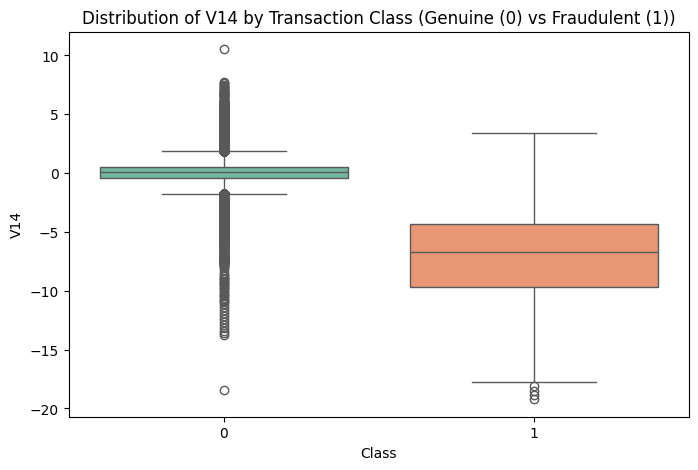

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Class", y="V14",data=df,palette="Set2")
plt.title("Distribution of V14 by Transaction Class (Genuine (0) vs Fraudulent (1))")
plt.show()

Separating features & targets

In [12]:
x = df.drop(columns="Class", axis=1)
y = df["Class"]

In [13]:
print(x)


            Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V20       V21  \
0       0.462388  0.239599  0.098698  0.363787  ...  0.25141

In [14]:
print(y)

0         0
1         0
2         0
3         0
4         0
         ..
284802    0
284803    0
284804    0
284805    0
284806    0
Name: Class, Length: 284807, dtype: int64


Splitting data into training data & test data

In [15]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size =0.2 , random_state=42, stratify=y)

In [16]:
print(x.shape , x_train.shape , x_test.shape)

(284807, 30) (227845, 30) (56962, 30)


Feature Scaling

In [17]:
scaler = StandardScaler()

x_train[["Time","Amount"]] = scaler.fit_transform(x_train[["Time","Amount"]])

x_test[["Time","Amount"]] = scaler.transform(x_test[["Time","Amount"]])

print(x_train[["Time","Amount"]].head())

            Time    Amount
265518  1.411588 -0.322494
180305  0.623141 -0.339764
42664  -1.130680  0.346693
198723  0.794699 -0.327360
82325  -0.748102 -0.008281


Class Balancing using ADASYN

In [18]:
adasyn = ADASYN(random_state=42 ,n_neighbors=5)

x_train_resampled, y_train_resampled = adasyn.fit_resample(x_train ,y_train)

Model Training & Evaluation

In [19]:
lgb_model = lgb.LGBMClassifier(random_state=42 , n_jobs=1)

lgb_model.fit(x_train_resampled , y_train_resampled)

[LightGBM] [Info] Number of positive: 227436, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.087543 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 454887, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499984 -> initscore=-0.000066
[LightGBM] [Info] Start training from score -0.000066


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [20]:
x_train_prediction = lgb_model.predict(x_train_resampled)

x_test_prediction = lgb_model.predict(x_test)

Classification Reports

In [21]:
print("-------- Training Prediction Report -----")

print(classification_report(y_train_resampled , x_train_prediction))

-------- Training Prediction Report -----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00    227436

    accuracy                           1.00    454887
   macro avg       1.00      1.00      1.00    454887
weighted avg       1.00      1.00      1.00    454887



In [22]:
print("-------- Test Prediction Report -----")

print(classification_report(y_test , x_test_prediction))

-------- Test Prediction Report -----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.39      0.88      0.54        98

    accuracy                           1.00     56962
   macro avg       0.69      0.94      0.77     56962
weighted avg       1.00      1.00      1.00     56962



Hyperparameter tuning

In [23]:
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'None',
        'random_state': 42,
        'n_jobs': -1,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'verbose': -1
    }
    
    # Mathematical constraint: num_leaves must be strictly less than 2^max_depth
    if params['num_leaves'] >= 2**params['max_depth']:
        params['num_leaves'] = 2**params['max_depth'] - 1

    # Train LightGBM on your ADASYN-resampled training data
    model = lgb.LGBMClassifier(**params)
    model.fit(x_train_resampled, y_train_resampled)
    
    # Predict probabilities on the raw, unseen testing data
    y_test_pred_proba = model.predict_proba(x_test)[:, 1]
    
    # Calculate AUPRC (Area Under the Precision-Recall Curve)
    auprc = average_precision_score(y_test, y_test_pred_proba)
    return auprc

# 2. Run the Optuna Study
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')

print("Starting Optuna optimization (Running 20 intelligent trials)...")
study.optimize(objective, n_trials=20)

print("\n=== Optimization Complete ===")
print(f"Best AUPRC Score Achieved: {study.best_value:.4f}")
print(f"Best Parameters: {study.best_params}")

Starting Optuna optimization (Running 20 intelligent trials)...



=== Optimization Complete ===
Best AUPRC Score Achieved: 0.8101
Best Parameters: {'learning_rate': 0.09881513024723627, 'max_depth': 6, 'num_leaves': 34, 'min_child_samples': 85, 'subsample': 0.910052915875964, 'colsample_bytree': 0.9871499721820404}


In [24]:
final_lgb_model = lgb.LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    **study.best_params  # This cleanly unpacks the exact winning parameters
)

# 2. Fit the model on the resampled training data
final_lgb_model.fit(x_train_resampled, y_train_resampled)

# 3. Predict probabilities and classes on the raw testing data
y_test_pred_proba_final = final_lgb_model.predict_proba(x_test)[:, 1]
final_test_predictions = final_lgb_model.predict(x_test)

# 4. Print final evaluation results
final_auprc = average_precision_score(y_test, y_test_pred_proba_final)
print("======= 🚀 FINAL OPTIMIZED LIGHTGBM EVALUATION =======")
print(f"Final Test AUPRC: {final_auprc:.4f}\n")
print(classification_report(y_test, final_test_predictions))

======= 🚀 FINAL OPTIMIZED LIGHTGBM EVALUATION =======
Final Test AUPRC: 0.8101

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.21      0.86      0.33        98

    accuracy                           0.99     56962
   macro avg       0.60      0.93      0.67     56962
weighted avg       1.00      0.99      1.00     56962



In [25]:
optimized_threshold = 0.80
threshold_predictions = np.where(y_test_pred_proba_final >= optimized_threshold, 1, 0)

# 2. Check the new hard metrics
print(f"======= 🎯 FINAL METRICS WITH THRESHOLD = {optimized_threshold} =======")
print(classification_report(y_test, threshold_predictions))

======= 🎯 FINAL METRICS WITH THRESHOLD = 0.8 =======
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.47      0.83      0.60        98

    accuracy                           1.00     56962
   macro avg       0.74      0.91      0.80     56962
weighted avg       1.00      1.00      1.00     56962



In [26]:
joblib.dump(scaler, 'fraud_scaler.pkl')
joblib.dump(final_lgb_model, 'fraud_lightgbm_model.pkl')

print("Artifacts successfully serialized to disk!")

Artifacts successfully serialized to disk!
